In [87]:
import numpy as np
import matplotlib.pyplot as plt
import io
import time
import random
import math
from robot_client import RobotClient, OscListener
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, namedtuple
import cv2



from __future__ import annotations
import random
import argparse
import os
import signal
import sys
from pathlib import Path


import pygame

from src.config import load_config, set_seed
from src.environment import BraitenbergEnv
from src.geometry import inside_box
from src.pygame_view import PygameView

from src.config import load_config, set_seed

In [88]:
# cfg = load_config("config/config.yaml")
width = 240 #cfg['arena']['width']
height = 180 #cfg['arena']['height']

In [89]:
# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)


In [90]:
device

device(type='cuda')

In [91]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# Model

In [92]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))


class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [93]:
class DQN(nn.Module):

    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    # Called with either one element to determine next action, or a batch
    # during optimization. Returns tensor([[left0exp,right0exp]...]).
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

# Hyperparamters 

# Load Checkpoint (optional)

# Utilities for Real-World

In [ ]:
def list_checkpoints(root="outputs/dqn_runs", n=10):
    """Return up to n most-recently-modified checkpoint files under root
    (newest first), looking in both checkpoints/*.pt and policies/*.pt
    subfolders of every run directory.
    """
    root = Path(root)
    paths = list(root.glob("**/checkpoints/*.pt")) + list(root.glob("**/policies/*.pt"))
    paths.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return paths[:n]


def print_checkpoints(root="outputs/dqn_runs", n=10):
    """Print an indexed list of the n most recently-modified checkpoints, so
    you can pick an index to pass to load_checkpoint()."""
    paths = list_checkpoints(root, n)
    for i, p in enumerate(paths):
        print(f"[{i}] {p}")
    return paths


def load_checkpoint(selection, policy_net, target_net=None, root="outputs/dqn_runs", device=device):
    """Load a checkpoint into policy_net (and target_net, if given) in place.
    selection: index into list_checkpoints() (0 = most recently modified), or
    a direct path to a .pt file (from print_checkpoints() or elsewhere).
    Returns the raw checkpoint payload (episode, rewards, config, etc.).

    Uses weights_only=False: these checkpoints carry a plain-dict "config"
    alongside the tensors, which torch's weights_only safe-unpickler (default
    since torch 2.6) can't load — and on this torch 2.12 install, the
    weights_only path even fails outright with
    AttributeError: module 'torch' has no attribute '_utils'
    before it gets to the unsupported-type check. weights_only=False sidesteps
    both issues via plain pickle; safe here since these are our own training
    checkpoints, not files from an untrusted source.
    """
    if isinstance(selection, (str, Path)):
        path = Path(selection)
    else:
        candidates = list_checkpoints(root, n=selection + 1)
        if selection >= len(candidates):
            raise FileNotFoundError(f"Only found {len(candidates)} checkpoint(s) under {root}")
        path = candidates[selection]

    payload = torch.load(path, map_location=device, weights_only=False)
    state_dict = payload.get("policy_state_dict")
    if state_dict is None:
        raise KeyError(f"No policy_state_dict found in {path}")

    policy_net.load_state_dict(state_dict)
    if target_net is not None and "target_state_dict" in payload:
        target_net.load_state_dict(payload["target_state_dict"])

    episode_note = f" (episode {payload['episode']})" if "episode" in payload else ""
    print(f"Loaded checkpoint: {path}{episode_note}")
    return payload


def load_run_config(checkpoint_path):
    """Find and load the run_config.json saved alongside a checkpoint/policy
    file, returning its "config_after_overrides" dict — the actual resolved
    cfg (vehicle.max_linear_speed, simulation.dt, etc.) that run was trained
    with, which can differ from whatever's currently in config/config.yaml.
    checkpoint_path: a .pt file under <run_dir>/checkpoints/ or
    <run_dir>/policies/ — run_config.json lives at <run_dir>/run_config.json,
    so we walk up looking for it.
    """
    import json
    path = Path(checkpoint_path)
    for parent in path.parents:
        candidate = parent / "run_config.json"
        if candidate.exists():
            with candidate.open() as f:
                data = json.load(f)
            return data["config_after_overrides"]
    raise FileNotFoundError(f"No run_config.json found in any parent of {checkpoint_path}")


def make_action_space(cfg):
    """Same enumeration as BraitenbergEnv.make_action, computed directly from
    cfg so we don't need a live env instance just to know how many actions
    there are. Restricted to speeds {0, ±20, ±max_linear_speed} rather than a
    full ±max_linear_speed step-20 grid (see BraitenbergEnv.make_action).
    """
    max_speed = int(cfg["vehicle"]["max_linear_speed"])
    speeds = sorted({0, 20, -20, max_speed, -max_speed})
    return [[i, j] for i in speeds for j in speeds]


def build_policy_nets(cfg, device=device, hidden_dim=128, n_observations=9):
    """Construct fresh policy_net/target_net sized for this cfg, without
    instantiating BraitenbergEnv or calling reset(). n_observations defaults
    to 9 — BraitenbergEnv.build_state always returns a 9-dim vector regardless
    of env state (see BraitenbergEnv.state_dim). n_actions is derived from
    cfg['vehicle']['max_linear_speed'] via make_action_space, matching
    BraitenbergEnv.make_action()'s enumeration without needing the env.
    """
    n_actions = len(make_action_space(cfg))
    policy_net = DQN(n_observations, n_actions).to(device)
    target_net = DQN(n_observations, n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    return policy_net, target_net


# example usage:
# print_checkpoints()                              # see what's available, pick an index
# cfg = load_run_config(policy_path)               # the actual config that policy was trained with
# policy_net, target_net = build_policy_nets(cfg)  # no env.reset() needed
# load_checkpoint(0, policy_net, target_net)       # 0 = most recently modified

In [95]:


# corresponding corners in our state-space coordinate frame, center is 0,0,
# ordered [top-left, top-right, bottom-left, bottom-right]. Column 0 is the
# horizontal extent (±half_w) and column 1 the vertical extent (±half_h),
# matching how pixel_to_arena's output is consumed downstream as (x, y) with
# x_norm = x/half_w, y_norm = y/half_h.
_half_h = (height - 1) / 2.0
_half_w = (width - 1) / 2.0
ARENA_CORNERS_STATE = np.array([
    [-_half_w, _half_h],
    [_half_w, _half_h],
    [-_half_w, -_half_h],
    [_half_w, -_half_h],
], dtype=np.float32)

# The homography maps the 4 measured corners exactly onto ARENA_CORNERS_STATE,
# so any *interior* point's distance from another interior point only matches
# what the sim assumed if the real arena's physical size matches what the sim's
# width/height units were tuned to represent. If the physical play area is a
# different size, every distance (velocity in robot_to_state, the reward
# thresholds in BraitenbergEnv.reward_function) is off by a constant factor.
# Tune this once by comparing a known real-world distance to what
# pixel_to_arena reports for it, e.g.
# ARENA_SCALE = (known_real_distance / measured_arena_distance).
ARENA_SCALE = 1.0


def order_corners(pts):
    """Sort 4 arbitrary (x, y) raw camera-pixel points into
    [top-left, top-right, bottom-left, bottom-right] order by geometry,
    rather than trusting which physical corner each OSC field (/corners12 vs
    /corners34, and which half of its payload) is supposed to report — that
    manual labeling has repeatedly been wrong in practice (confirmed against
    live camera data: e.g. one /corners34 point was being assigned to the
    "top-left" slot when it was geometrically bottom-left). Assumes the 4
    points roughly form an upright rectangle in image space (y increases
    downward), which holds for an overhead-mounted, not-wildly-rotated
    camera: top-left has the smallest x+y, bottom-right the largest x+y;
    of the remaining two, top-right has the smaller (y - x), bottom-left the
    larger.
    """
    pts = np.asarray(pts, dtype=np.float32)
    s = pts.sum(axis=1)
    d = pts[:, 1] - pts[:, 0]
    top_left = pts[np.argmin(s)]
    bottom_right = pts[np.argmax(s)]
    top_right = pts[np.argmin(d)]
    bottom_left = pts[np.argmax(d)]
    return [tuple(top_left), tuple(top_right), tuple(bottom_left), tuple(bottom_right)]


def build_arena_homography(corners_px):
    """Build the pixel<->arena homography from 4 corners in raw camera pixel
    coordinates (in any order — see order_corners, which sorts them into
    [top-left, top-right, bottom-left, bottom-right] to match
    ARENA_CORNERS_STATE before building the transform). Returns
    (homography, inverse_homography) for use with pixel_to_arena/arena_to_pixel.
    """
    corners_px = np.asarray(order_corners(corners_px), dtype=np.float32)
    homography = cv2.getPerspectiveTransform(corners_px, ARENA_CORNERS_STATE)
    homography_inv = cv2.getPerspectiveTransform(ARENA_CORNERS_STATE, corners_px)
    return homography, homography_inv


def pixel_to_arena(px, py, homography):
    """Map a raw camera pixel coordinate to (x, y) in the state-space
    coordinate frame, using the live homography from build_arena_homography
    (built from Bonsai's /corners12+/corners34 each run — there's no
    hardcoded fallback, since the camera/arena calibration can drift).
    ARENA_SCALE corrects for the real arena's physical size not matching what
    the sim's width/height units were tuned to represent (see ARENA_SCALE above).
    """
    pt = np.array([[[px, py]]], dtype=np.float32)
    mapped = cv2.perspectiveTransform(pt, homography)
    return float(mapped[0, 0, 0]) * ARENA_SCALE, float(mapped[0, 0, 1]) * ARENA_SCALE


def arena_to_pixel(x, y, homography_inv):
    """Map a state-space (x, y) coordinate back to raw camera pixel coordinates
    (the inverse of pixel_to_arena), e.g. for overlaying the goal region on the
    live camera frame. Undoes ARENA_SCALE before inverting the homography.
    """
    pt = np.array([[[x / ARENA_SCALE, y / ARENA_SCALE]]], dtype=np.float32)
    mapped = cv2.perspectiveTransform(pt, homography_inv)
    return float(mapped[0, 0, 0]), float(mapped[0, 0, 1])


def vector_to_orientation(dx, dy):
    """Heading angle (radians) of the green->red vector, in the same convention
    as the simulation: heading=0 points along +x, increasing counter-clockwise,
    so x += cos(heading), y += sin(heading) (see DifferentialDriveVehicle.update).
    dx, dy must already be in arena state-space coordinates (i.e. after
    pixel_to_arena), not raw camera pixels.
    """
    return math.atan2(dy, dx)


def has_invalid_marker(robot_data):
    """Bonsai sends -1 for any marker (red/green) it couldn't detect in the current frame."""
    return any(v == -1 for v in robot_data)


def robot_to_state(robot_data, red_data, green_data, homography, prev_xy=None, dt=None):
    """Convert the robot's two-marker camera readout into the same 9-dim state
    vector used by the DQN in simulation (see BraitenbergEnv.build_state):
    [x_norm, y_norm, sin_theta, cos_theta, norm_vel, norm_green_x, norm_green_y, norm_red_x, norm_red_y].
    robot_data: [x_red, y_red, x_green, y_green] markers mounted on our robot
    (front/back), in raw camera pixel coordinates — used for position + heading.
    red_data: [x, y] raw pixel position of the red (avoid) stimulus robot.
    green_data: [x, y] raw pixel position of the green (target) stimulus robot.
    homography: pixel->arena homography from build_arena_homography, built
    from this run's live /corners12+/corners34 readings.
    prev_xy/dt: previous arena-frame (x, y) and elapsed time, for velocity; if
    omitted (e.g. first step) norm_vel is reported as 0.
    """
    x_red_px, y_red_px, x_green_px, y_green_px = robot_data
    x_red_aux_px, y_red_aux_px = red_data
    x_green_aux_px, y_green_aux_px = green_data

    # stimulus robots (red = avoid, green = target)
    x_aux_red, y_aux_red = pixel_to_arena(x_red_aux_px, y_red_aux_px, homography)
    x_aux_green, y_aux_green = pixel_to_arena(x_green_aux_px, y_green_aux_px, homography)

    # our robot's own front/back markers -> position + heading
    x_red, y_red = pixel_to_arena(x_red_px, y_red_px, homography)
    x_green, y_green = pixel_to_arena(x_green_px, y_green_px, homography)

    heading = vector_to_orientation(x_red - x_green, y_red - y_green)  # radians, matches sim's heading convention
    sin_theta = math.sin(heading)
    cos_theta = math.cos(heading)

    half_w = width / 2.0
    half_h = height / 2.0

    x_norm = x_red / half_w
    y_norm = y_red / half_h

    print(f"robot_to_state: half_w={half_w:.2f}, half_h={half_h:.2f}")
    print(f"robot_to_state: x_red={x_red:.2f}, y_red={y_red:.2f}, x_green={x_green:.2f}, y_green={y_green:.2f}, heading={heading:.2f} rad, sin_theta={sin_theta:.2f}, cos_theta={cos_theta:.2f}")
    print(f"robot_to_state: x_aux_red={x_aux_red:.2f}, y_aux_red={y_aux_red:.2f}, x_aux_green={x_aux_green:.2f}, y_aux_green={y_aux_green:.2f}")
    if prev_xy is None or dt is None:
        norm_vel = 0.0
    else:
        prev_x, prev_y = prev_xy
        agent_vel = np.sqrt((x_red - prev_x) ** 2 + (y_red - prev_y) ** 2) / dt
        norm_vel = agent_vel / float(cfg['vehicle']['max_linear_speed'])

    norm_red_x = x_aux_red / half_w
    norm_red_y = y_aux_red / half_h
    norm_green_x = x_aux_green / half_w
    norm_green_y = y_aux_green / half_h

    return np.array(
            [
                x_norm,
                y_norm,
                sin_theta,
                cos_theta,
                norm_vel,
                norm_green_x,
                norm_green_y,
                norm_red_x,
                norm_red_y,
            ],
            dtype=np.float32,
        )


In [96]:
def clip_motor_speed(speed, max_action_speed, min_speed=30, max_speed=60):
    """Linearly map a motor command's magnitude from the policy's action
    range [0, max_action_speed] (max_action_speed = cfg['vehicle']['max_linear_speed'],
    the largest magnitude the DQN's action grid can output) onto the motor's
    usable range [min_speed, max_speed] (the motors stall below ~min_speed
    and shouldn't be driven past max_speed), preserving sign.

    A plain floor (clip to at least min_speed) collapses every nonzero
    action to the same ±min_speed whenever min_speed > max_action_speed —
    e.g. with min_speed=30 and actions in {10, 30}, both 10 and 30 floor to
    30, so every command looks identical regardless of which action the
    policy actually picked. Scaling proportionally instead preserves that
    the policy chose a bigger or smaller action.
    """
    if speed == 0:
        return 0.0
    magnitude = min(abs(speed), max_action_speed)
    scaled = min_speed + (magnitude / max_action_speed) * (max_speed - min_speed)
    return float(math.copysign(scaled, speed))


def sample_corners(corners_live, n_samples=8, sample_interval=0.05):
    """Collect n_samples readings of the live [top-left, top-right, bottom-left,
    bottom-right] corner list (mutated in place by the /corners12 and
    /corners34 OSC callbacks) and return their per-corner median, so a single
    noisy frame can't shift the calibration. corners_live: the same list
    object the on_corners12/on_corners34 callbacks write into. Returns None if
    any corner never got a reading during the sampling window.
    """
    samples = [[], [], [], []]
    for _ in range(n_samples):
        time.sleep(sample_interval)
        for i, c in enumerate(corners_live):
            if c is not None:
                samples[i].append(c)
    if any(len(s) == 0 for s in samples):
        return None
    return [tuple(np.median(np.array(s), axis=0)) for s in samples]


def refresh_corners_if_valid(corners_live, robot_data, aux_data, valid_state, n_samples=8, sample_interval=0.05):
    """Re-calibrate the pixel<->arena homography from fresh corner samples, but
    only commit the update if every tracked marker (robot front/back + both
    stimulus robots) lands inside the resulting arena bounds (checked with
    src.geometry.inside_box, the same boundary check BraitenbergEnv uses for
    termination). This avoids recalibrating on every step (which would just
    chase camera/corner-marker jitter) and avoids ever committing a
    homography that puts a vehicle outside the arena (which usually means the
    new corner samples are bad, not that the vehicle is really out of
    bounds).

    valid_state: dict with keys 'homography', 'homography_inv', 'corners' —
    the last known-valid calibration. Updated in place when the new corners
    pass validation; left untouched (so callers keep using the last valid
    one) when they don't.
    Returns (homography, homography_inv) — either the freshly validated one
    or the previous valid_state if validation failed.
    """
    new_corners = sample_corners(corners_live, n_samples=n_samples, sample_interval=sample_interval)
    if new_corners is None:
        return valid_state['homography'], valid_state['homography_inv']

    homography, homography_inv = build_arena_homography(new_corners)

    marker_points_px = [tuple(robot_data[:2]), tuple(robot_data[2:]), tuple(aux_data[:2]), tuple(aux_data[2:])]
    all_inside = all(
        inside_box(np.array(pixel_to_arena(px, py, homography)), width, height)
        for px, py in marker_points_px
    )

    if all_inside:
        valid_state['corners'] = new_corners
        valid_state['homography'] = homography
        valid_state['homography_inv'] = homography_inv

    return valid_state['homography'], valid_state['homography_inv']

In [97]:
def run_rollout_REAL(policy_net, env, max_steps=None, device=device, position_timeout=5.0,
                      corner_refresh_steps=10, corner_n_samples=8):
    """Greedy rollout of a trained policy_net in BraitenbergEnv (no exploration).
    corner_refresh_steps: re-sample /corners12+/corners34 every this many
    steps instead of every step (the corner markers are noisy frame-to-frame,
    so recalibrating constantly just chases that noise). corner_n_samples:
    how many corner readings to median together each refresh — see
    sample_corners/refresh_corners_if_valid.
    """
    robot = RobotClient()
    positions = None
    try:
        robot.start()
        policy_net.eval()
        robot_data = [0, 0, 0, 0]  # [x_red, y_red, x_green, y_green] (raw camera pixels, our robot's markers)
        aux_data = [0, 0, 0, 0]  # [x_red, y_red, x_green, y_green] (raw camera pixels, stimulus robots)
        corners = [None, None, None, None]  # [top-left, top-right, bottom-left, bottom-right] (raw camera pixels)
        got_position = False
        got_aux = False

        def on_robot(args):
            nonlocal got_position
            robot_data[:] = args
            got_position = True

        def on_auxrobots(args):
            nonlocal got_aux
            aux_data[:] = args
            got_aux = True

        def on_corners12(args):
            # /corners12 actually carries [top-right, bottom-right] in that
            # pixel order (confirmed against the live camera) — write them into
            # the [top-left, top-right, bottom-left, bottom-right] slots
            # ARENA_CORNERS_STATE expects.
            corners[1] = (args[0], args[1])  # top-right
            corners[3] = (args[2], args[3])  # bottom-right

        def on_corners34(args):
            # /corners34 carries [top-left, bottom-left] in that pixel order.
            corners[0] = (args[0], args[1])  # top-left
            corners[2] = (args[2], args[3])  # bottom-left

        positions = OscListener(port=9000)
        positions.subscribe("/robot", on_robot)
        positions.subscribe("/auxrobots", on_auxrobots)
        positions.subscribe("/corners12", on_corners12)
        positions.subscribe("/corners34", on_corners34)
        positions.start()

        waited = 0.0
        while not (got_position and got_aux and all(c is not None for c in corners)) and waited < position_timeout:
            time.sleep(0.1)
            waited += 0.1
        if not (got_position and got_aux and all(c is not None for c in corners)):
            raise RuntimeError(f"Timed out after {position_timeout}s waiting for /robot, /auxrobots and /corners12+/corners34 from Bonsai")

        if has_invalid_marker(robot_data) or has_invalid_marker(aux_data):
            raise RuntimeError("Marker not detected at start — check camera/tracking before running.")

        homography, homography_inv = build_arena_homography(corners)  # initial calibration from this run's /corners12+/corners34
        valid_state = {'corners': list(corners), 'homography': homography, 'homography_inv': homography_inv}

        half_w = width / 2.0
        half_h = height / 2.0
        action_space = make_action_space(cfg)  # [left, right] motor pairs, same enumeration as BraitenbergEnv.make_action
        max_action_speed = float(cfg['vehicle']['max_linear_speed'])  # largest |speed| the action grid can output, for clip_motor_speed's scaling
        red_data, green_data = aux_data[:2], aux_data[2:]
        state = robot_to_state(robot_data, red_data, green_data, homography=homography)  # uses real pixel coords to grab state for policy
        prev_xy = (state[0] * half_w, state[1] * half_h)
        last_state_time = time.time()  # wall-clock time of the last state read, for measuring real elapsed dt below
        use_random_action = False  # forced to True for one step whenever the previous step's mapped position fell outside the arena

        max_steps = max_steps or cfg['simulation']['max_steps']

        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        trajectory = {'x': [], 'y': [], 'red_x': [], 'red_y': [], 'green_x': [], 'green_y': []}
        rewards = []
        terminated = False

        for t in range(max_steps):

            # re-calibrate corners periodically (not every step) and only if
            # every marker still lands inside the resulting arena bounds —
            # otherwise keep using the last known-valid homography (see
            # refresh_corners_if_valid).
            if t > 0 and t % corner_refresh_steps == 0:
                homography, homography_inv = refresh_corners_if_valid(
                    corners, robot_data, aux_data, valid_state, n_samples=corner_n_samples
                )

            if use_random_action:
                # last step's homography-mapped position was outside the
                # arena, so the state we'd be acting on is unreliable —
                # don't trust the policy's argmax on bad data, just take a
                # random action this step instead.
                action_idx = random.randrange(len(action_space))
                print("Using a random action: previous position reading was outside the arena.")
            else:
                with torch.no_grad():
                    action_idx = policy_net(state_t).max(1).indices.item()

            # the DQN outputs an action index, not motor values directly — look it
            # up in action_space the same way BraitenbergEnv.step does for
            # "Case 1: DQN action index" (see environment.py)
            left, right = action_space[action_idx]
            duration = 0.5

            left_cmd = clip_motor_speed(left, max_action_speed)
            right_cmd = clip_motor_speed(right, max_action_speed)
            robot.set_wheels(left_cmd, right_cmd)  # drive, scaled to the motors' usable range
            print(f" Wheels: (L={left_cmd}, R={right_cmd})s")
            time.sleep(duration)  # pauses

            robot.set_wheels(0, 0)  # stop moving before reading position
            red_data, green_data = aux_data[:2], aux_data[2:]
            if has_invalid_marker(robot_data) or has_invalid_marker(aux_data):
                print("Warning: marker not detected this step, keeping previous state.")
            else:
                # use the actual measured wall-clock time since the last state
                # read for norm_vel, not cfg's training-time dt — the real loop's
                # cycle time (sleep + inference + occasional corner resampling)
                # doesn't match the sim's fixed dt, so using cfg's dt here was
                # producing wildly wrong/inconsistent velocity values.
                now = time.time()
                actual_dt = now - last_state_time
                last_state_time = now
                state = robot_to_state(robot_data, red_data, green_data, prev_xy=prev_xy, dt=actual_dt, homography=homography)
                prev_xy = (state[0] * half_w, state[1] * half_h)

            # pull this step's coords out of the homography-mapped state and
            # gate them on inside_box (the same arena-boundary check
            # BraitenbergEnv uses for termination) — a bad homography/marker
            # read can put a point miles outside the arena. Rather than
            # substituting a fallback position, we use the raw coords as-is
            # for reward/trajectory and instead force a random action next
            # step (set above), since the policy shouldn't be trusted to act
            # on a state we know is bad.
            vehicle_xy = (state[0] * half_w, state[1] * half_h)
            green_xy = (state[5] * half_w, state[6] * half_h)
            red_xy = (state[7] * half_w, state[8] * half_h)

            if (inside_box(np.array(vehicle_xy), width, height)
                    and inside_box(np.array(green_xy), width, height)
                    and inside_box(np.array(red_xy), width, height)):
                use_random_action = False
            else:
                print("Warning: homography-mapped coords fell outside the arena — next action will be random.")
                use_random_action = True

            trajectory['x'].append(vehicle_xy[0])
            trajectory['y'].append(vehicle_xy[1])
            trajectory['red_x'].append(red_xy[0])
            trajectory['red_y'].append(red_xy[1])
            trajectory['green_x'].append(green_xy[0])
            trajectory['green_y'].append(green_xy[1])

            # reuse BraitenbergEnv's own reward_function instead of a
            # reimplementation, by writing the homography-derived coords
            # straight into the env's state.
            env.vehicle.state.x, env.vehicle.state.y = vehicle_xy
            env.red_pos = np.array(red_xy)
            env.green_pos = np.array(green_xy)
            reward = env.reward_function()
            rewards.append(reward)

            # mirrors the sim's reward shaping — a hit pushes the reward to roughly
            # +/-100, so we treat that as a stand-in for "terminated" on real hardware
            #add if distance to red < threshold or distance to green < threshold, then terminate
            # if np.linalg.norm(np.array(vehicle_xy) - np.array(red_xy)) < 5:
            #     print("Hit red — terminating rollout.")
            #     terminated = True
            #     break
            if np.linalg.norm(np.array(vehicle_xy) - np.array(green_xy)) < 35:
                print("Reached green — terminating rollout.")
                terminated = True
                break


            if reward >= 100 or reward <= -100:
                terminated = True
                break

            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            print(f"Step {t}: reward={reward:.2f}, state={state}, action_idx={action_idx}, vehicle_xy={vehicle_xy}, green_xy={green_xy}, red_xy={red_xy}")
        print("Goal reached!" if terminated and rewards[-1] >= 100 else
              "Hit red — terminated." if terminated else
              "Max steps reached without reaching goal.")
        robot.set_wheels(0, 0)

        policy_net.train()
        return trajectory, rewards
    finally:
        # always release the motors and tear down the OSC listener, even if a
        # marker timeout or other error aborted the rollout partway through.
        robot.set_wheels(0, 0)
        robot.stop()
        if positions is not None:
            positions.stop()

In [98]:
# aux = [red_x, red_y, green_x, green_y] 

[OSC port=9000] ('192.168.0.100', 9001) /corners12 [1221, 118, 187, 74]
[OSC port=9000] ('192.168.0.100', 9001) /corners34 [149, 975, 1173, 1031]
[OSC port=9000] ('192.168.0.100', 9001) /auxrobots [677, 505, 782, 1000]
[OSC port=9000] ('192.168.0.100', 9001) /robot [382, 576, 391, 540]
[OSC port=9000] ('192.168.0.100', 9001) /corners12 [1221, 118, 187, 74]
[OSC port=9000] ('192.168.0.100', 9001) /corners34 [149, 975, 1173, 1031]
[OSC port=9000] ('192.168.0.100', 9001) /auxrobots [677, 505, 782, 1000]


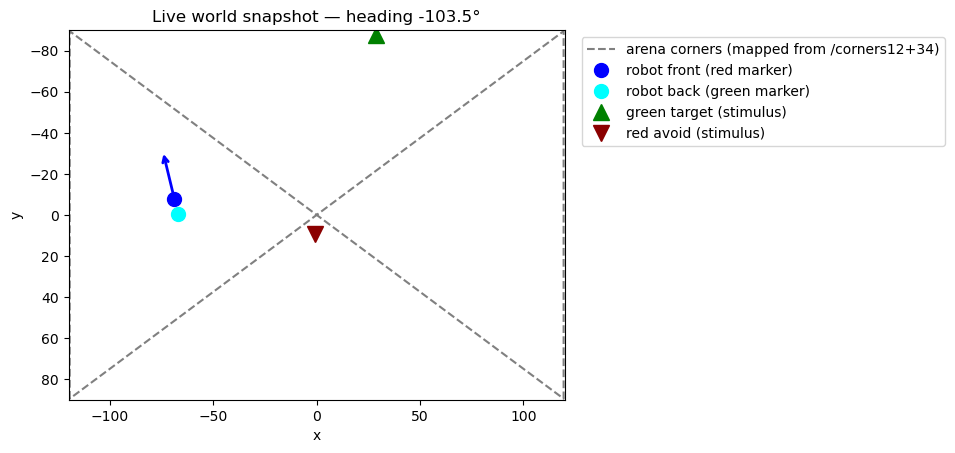

robot front (red):  pixel=[382, 576]  -> arena=(-68.8, -7.7)
robot back (green): pixel=[391, 540]  -> arena=(-67.1, -0.5)
heading: -1.806 rad (-103.5 deg)
green stimulus: pixel=[782, 1000]  -> arena=(28.9, -87.6)
red stimulus:   pixel=[677, 505]  -> arena=(-0.9, 9.1)
mapped corners (compare against ARENA_CORNERS_STATE / expected half-extents ±120.0 x, ±90.0 y):
  corner[0] px=(187, 74) -> arena=(-119.5, 89.5)
  corner[1] px=(149, 975) -> arena=(-119.5, -89.5)
  corner[2] px=(1221, 118) -> arena=(119.5, 89.5)
  corner[3] px=(1173, 1031) -> arena=(119.5, -89.5)
Distance to red stimulus: 69.9
Distance to green stimulus: 126.2


{'robot_data': [382, 576, 391, 540],
 'aux_data': [677, 505, 782, 1000],
 'corners_px': [(187, 74), (149, 975), (1221, 118), (1173, 1031)],
 'corners_arena': [(-119.5, 89.5),
  (-119.5, -89.5),
  (119.5, 89.5),
  (119.5, -89.5)],
 'homography': array([[ 2.32718470e-01,  1.10163407e-02, -1.64059667e+02],
        [ 9.61925993e-03, -1.97738587e-01,  1.02503195e+02],
        [ 1.38649447e-05, -9.46842352e-06,  1.00000000e+00]]),
 'vehicle_xy': (-68.82662963867188, -7.720889091491699),
 'heading': -1.8063182539348324,
 'green_xy': (28.90280532836914, -87.59278106689453),
 'red_xy': (-0.9416742920875549, 9.115470886230469)}

In [99]:
def debug_world_snapshot(position_timeout=5.0):
    """Grab one reading of /robot, /auxrobots, /corners12+/corners34 from
    Bonsai, run it through the same pixel->arena homography run_rollout_REAL
    uses, and plot the result — so you can sanity-check the mapping (and see
    where the robot/targets land in arena space) before driving anything.
    Doesn't touch the wheels.
    """
    robot_data = [0, 0, 0, 0]
    aux_data = [0, 0, 0, 0]
    corners = [None, None, None, None]
    got_position = False
    got_aux = False

    def on_robot(args):
        nonlocal got_position
        robot_data[:] = args
        got_position = True

    def on_auxrobots(args):
        nonlocal got_aux
        aux_data[:] = args
        got_aux = True

    def on_corners12(args):
        # /corners12 carries [top-right, bottom-right] in that pixel order.
        corners[2] = (args[0], args[1])  # top-right
        corners[0] = (args[2], args[3])  # bottom-right

    def on_corners34(args):
        # /corners34 carries [top-left, bottom-left] in that pixel order.
        corners[1] = (args[0], args[1])  # top-left
        corners[3] = (args[2], args[3])  # bottom-left

    positions = OscListener(port=9000)
    positions.subscribe("/robot", on_robot)
    positions.subscribe("/auxrobots", on_auxrobots)
    positions.subscribe("/corners12", on_corners12)
    positions.subscribe("/corners34", on_corners34)
    positions.start()

    waited = 0.0
    while not (got_position and got_aux and all(c is not None for c in corners)) and waited < position_timeout:
        time.sleep(0.1)
        waited += 0.1
    positions.stop()

    if not (got_position and got_aux and all(c is not None for c in corners)):
        raise RuntimeError(f"Timed out after {position_timeout}s waiting for /robot, /auxrobots and /corners12+/corners34 from Bonsai")
    if has_invalid_marker(robot_data) or has_invalid_marker(aux_data):
        raise RuntimeError("Marker not detected — check camera/tracking before running.")

    homography, _ = build_arena_homography(corners)

    x_red_px, y_red_px, x_green_px, y_green_px = robot_data
    x_red_stim_px, y_red_stim_px = aux_data[:2]
    x_green_stim_px, y_green_stim_px = aux_data[2:]

    x_red, y_red = pixel_to_arena(x_red_px, y_red_px, homography)
    x_green, y_green = pixel_to_arena(x_green_px, y_green_px, homography)
    x_red_stim, y_red_stim = pixel_to_arena(x_red_stim_px, y_red_stim_px, homography)
    x_green_stim, y_green_stim = pixel_to_arena(x_green_stim_px, y_green_stim_px, homography)
    corners_arena = [pixel_to_arena(px, py, homography) for px, py in corners]

    heading = vector_to_orientation(x_red - x_green, y_red - y_green)

    half_w = width / 2.0
    half_h = height / 2.0
    arrow_len = 0.1 * max(width, height)

    fig, ax = plt.subplots()
    cx = [c[0] for c in corners_arena] + [corners_arena[0][0]]
    cy = [c[1] for c in corners_arena] + [corners_arena[0][1]]
    ax.plot(cx, cy, '--', color='gray', label='arena corners (mapped from /corners12+34)')

    ax.plot(x_red, y_red, 'o', color='blue', markersize=10, label='robot front (red marker)')
    ax.plot(x_green, y_green, 'o', color='cyan', markersize=10, label='robot back (green marker)')
    ax.annotate('', xy=(x_red + arrow_len * math.cos(heading), y_red + arrow_len * math.sin(heading)),
                xytext=(x_red, y_red), arrowprops=dict(arrowstyle='->', color='blue', lw=2))

    ax.plot(x_green_stim, y_green_stim, '^', color='green', markersize=12, label='green target (stimulus)')
    ax.plot(x_red_stim, y_red_stim, 'v', color='darkred', markersize=12, label='red avoid (stimulus)')

    ax.set_xlim(-half_w, half_w)
    ax.set_ylim(half_h, -half_h)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f"Live world snapshot — heading {math.degrees(heading):.1f}°")
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.show()

    print(f"robot front (red):  pixel={robot_data[:2]}  -> arena=({x_red:.1f}, {y_red:.1f})")
    print(f"robot back (green): pixel={robot_data[2:]}  -> arena=({x_green:.1f}, {y_green:.1f})")
    print(f"heading: {heading:.3f} rad ({math.degrees(heading):.1f} deg)")
    print(f"green stimulus: pixel={aux_data[2:]}  -> arena=({x_green_stim:.1f}, {y_green_stim:.1f})")
    print(f"red stimulus:   pixel={aux_data[:2]}  -> arena=({x_red_stim:.1f}, {y_red_stim:.1f})")
    print("mapped corners (compare against ARENA_CORNERS_STATE / expected half-extents"
          f" ±{half_w:.1f} x, ±{half_h:.1f} y):")
    for i, c in enumerate(corners_arena):
        print(f"  corner[{i}] px={corners[i]} -> arena=({c[0]:.1f}, {c[1]:.1f})")

    #print distanc between robot and aux robots
    dist_red = np.linalg.norm(np.array([x_red, y_red]) - np.array([x_red_stim, y_red_stim]))
    dist_green = np.linalg.norm(np.array([x_red, y_red]) - np.array([x_green_stim, y_green_stim]))
    print(f"Distance to red stimulus: {dist_red:.1f}")
    print(f"Distance to green stimulus: {dist_green:.1f}")

    return {
        "robot_data": robot_data,
        "aux_data": aux_data,
        "corners_px": corners,
        "corners_arena": corners_arena,
        "homography": homography,
        "vehicle_xy": (x_red, y_red),
        "heading": heading,
        "green_xy": (x_green_stim, y_green_stim),
        "red_xy": (x_red_stim, y_red_stim),
    }


# run this before driving the robot, to sanity-check the pixel->arena mapping:
debug_world_snapshot()

Loaded checkpoint: C:\Users\LoveTriangle\Documents\LoveTriangle_robots\outputs\dqn_runs\config_cond-multi-blocking-orbit-separated_seed-7_training.lr=0.0001_training.eps_decay=20000_training.gamma=0.99_vehicle.max_linear_speed=30.0_simulation.dt=0.16\multi-blocking-orbit-separated\20260624_135130\policies\final_policy.pt
[OSC port=9000] ('192.168.0.100', 9001) /corners12 [1221, 118, 187, 74]
[OSC port=9000] ('192.168.0.100', 9001) /corners34 [149, 975, 1173, 1031]
[OSC port=9000] ('192.168.0.100', 9001) /auxrobots [677, 505, 782, 1000]
[OSC port=9000] ('192.168.0.100', 9001) /robot [382, 576, 391, 540]
[OSC port=9000] ('192.168.0.100', 9001) /corners12 [1221, 118, 187, 74]
[OSC port=9000] ('192.168.0.100', 9001) /corners34 [149, 975, 1173, 1031]
[OSC port=9000] ('192.168.0.100', 9001) /auxrobots [677, 505, 782, 1000]
[OSC port=9000] ('192.168.0.100', 9001) /robot [382, 576, 391, 540]
[OSC port=9000] ('192.168.0.100', 9001) /corners12 [1221, 118, 187, 74]


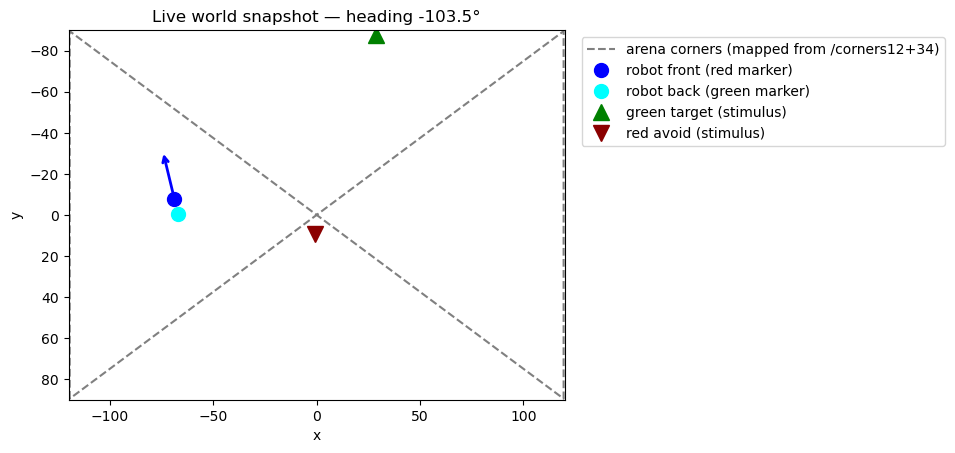

robot front (red):  pixel=[382, 576]  -> arena=(-68.8, -7.7)
robot back (green): pixel=[391, 540]  -> arena=(-67.1, -0.5)
heading: -1.806 rad (-103.5 deg)
green stimulus: pixel=[782, 1000]  -> arena=(28.9, -87.6)
red stimulus:   pixel=[677, 505]  -> arena=(-0.9, 9.1)
mapped corners (compare against ARENA_CORNERS_STATE / expected half-extents ±120.0 x, ±90.0 y):
  corner[0] px=(187, 74) -> arena=(-119.5, 89.5)
  corner[1] px=(149, 975) -> arena=(-119.5, -89.5)
  corner[2] px=(1221, 118) -> arena=(119.5, 89.5)
  corner[3] px=(1173, 1031) -> arena=(119.5, -89.5)
Distance to red stimulus: 69.9
Distance to green stimulus: 126.2
[OSC port=9000] ('192.168.0.100', 9001) /corners12 [1221, 118, 187, 74]
[OSC port=9000] ('192.168.0.100', 9001) /corners34 [149, 975, 1173, 1031]
[OSC port=9000] ('192.168.0.100', 9001) /auxrobots [677, 505, 782, 1000]
[OSC port=9000] ('192.168.0.100', 9001) /robot [382, 576, 391, 540]
[OSC port=9000] ('192.168.0.100', 9001) /corners12 [1221, 118, 187, 74]
[OSC port=

In [100]:
# Load a specific policy/checkpoint by path and run it on the real robot.
policy_path = "C:\\Users\\LoveTriangle\\Documents\\LoveTriangle_robots\\outputs\\dqn_runs\\config_cond-multi-blocking-orbit-separated_seed-7_training.lr=0.0001_training.eps_decay=20000_training.gamma=0.99_vehicle.max_linear_speed=30.0_simulation.dt=0.16\\multi-blocking-orbit-separated\\20260624_135130\\policies\\final_policy.pt"
cfg = load_run_config(policy_path)  # the actual config that specific run was trained with, not config/config.yaml
env = BraitenbergEnv(cfg, cfg.get("condition"))  # make a fresh env for the rollout
policy_net, target_net = build_policy_nets(cfg)  # sized from cfg directly, no env.reset() needed
load_checkpoint(policy_path, policy_net, target_net)

debug_world_snapshot()  # sanity-check the live pixel->arena mapping before driving

trajectory, rewards = run_rollout_REAL(policy_net, env)